In [3]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

# **_Import Dataset_**

In [5]:
df = pd.read_csv("EV_Charging_Station_Usage.csv")

# **_Check data_**

In [6]:
df.head

<bound method NDFrame.head of     Station_ID       City        Date Vehicle_Type Charging_Start_Time  \
0        ST001    Kolkata  2025-10-15          Car               12:14   
1        ST002       Pune  2025-10-15          Bus               15:27   
2        ST003  Hyderabad  2025-10-15          Car               11:29   
3        ST004     Indore  2025-10-15          Bus               10:12   
4        ST005     Indore  2025-10-15          Car               10:19   
..         ...        ...         ...          ...                 ...   
495      ST496     Indore  2025-10-15          Bus               16:39   
496      ST497  Ahmedabad  2025-10-15          Car               10:21   
497      ST498      Delhi  2025-10-15        Truck               16:55   
498      ST499     Bhopal  2025-10-15        Truck               12:59   
499      ST500     Bhopal  2025-10-15         Bike               11:34   

    Charging_End_Time  Energy_Consumed_kWh  Cost_INR Payment_Method  
0          

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Station_ID           500 non-null    object 
 1   City                 500 non-null    object 
 2   Date                 500 non-null    object 
 3   Vehicle_Type         500 non-null    object 
 4   Charging_Start_Time  500 non-null    object 
 5   Charging_End_Time    500 non-null    object 
 6   Energy_Consumed_kWh  500 non-null    float64
 7   Cost_INR             500 non-null    float64
 8   Payment_Method       500 non-null    object 
dtypes: float64(2), object(7)
memory usage: 35.3+ KB


In [8]:
df.shape

(500, 9)

In [9]:
df.describe

<bound method NDFrame.describe of     Station_ID       City        Date Vehicle_Type Charging_Start_Time  \
0        ST001    Kolkata  2025-10-15          Car               12:14   
1        ST002       Pune  2025-10-15          Bus               15:27   
2        ST003  Hyderabad  2025-10-15          Car               11:29   
3        ST004     Indore  2025-10-15          Bus               10:12   
4        ST005     Indore  2025-10-15          Car               10:19   
..         ...        ...         ...          ...                 ...   
495      ST496     Indore  2025-10-15          Bus               16:39   
496      ST497  Ahmedabad  2025-10-15          Car               10:21   
497      ST498      Delhi  2025-10-15        Truck               16:55   
498      ST499     Bhopal  2025-10-15        Truck               12:59   
499      ST500     Bhopal  2025-10-15         Bike               11:34   

    Charging_End_Time  Energy_Consumed_kWh  Cost_INR Payment_Method  
0      

# **_Data Cleaning_**

In [77]:
df.isnull().sum()   #Missing Values Check

station_id             0
city                   0
date                   0
vehicle_type           0
charging_start_time    0
charging_end_time      0
energy_consumed_kwh    0
cost_inr               0
payment_method         0
hour                   0
day                    0
month                  0
peak_hour              0
revenue                0
charging_time          0
available_time         0
utilization            0
day_name               0
week_type              0
dtype: int64

In [12]:
df.dropna()  #Handle missing values

,Station_ID,City,Date,Vehicle_Type,Charging_Start_Time,Charging_End_Time,Energy_Consumed_kWh,Cost_INR,Payment_Method
0,ST001,Kolkata,2025-10-15,Car,12:14,13:57,96.2,962.0,UPI
1,ST002,Pune,2025-10-15,Bus,15:27,17:26,59.2,592.0,UPI
2,ST003,Hyderabad,2025-10-15,Car,11:29,12:08,59.8,598.0,Cash
3,ST004,Indore,2025-10-15,Bus,10:12,11:45,38.3,383.0,Cash
4,ST005,Indore,2025-10-15,Car,10:19,11:03,48.9,489.0,Card
...,...,...,...,...,...,...,...,...,...
495,ST496,Indore,2025-10-15,Bus,16:39,19:15,44.2,442.0,Cash
496,ST497,Ahmedabad,2025-10-15,Car,10:21,13:18,18.2,182.0,Card
497,ST498,Delhi,2025-10-15,Truck,16:55,18:21,30.8,308.0,Cash
498,ST499,Bhopal,2025-10-15,Truck,12:59,14:15,20.0,200.0,Card


In [79]:
df.drop_duplicates(inplace=True)    #Remove Duplicates

In [80]:
df['date'] = pd.to_datetime(df['date'])   #Fix Data Types

In [81]:
df.columns = df.columns.str.lower()   #Rename Columns

# **_Feature Engineering_**

#### _Time Features_

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df['Date']=pd.to_datetime(df['Date'])

In [15]:
df.columns = df.columns.str.lower()

In [16]:
df['hour'] = df['date'].dt.hour

In [18]:
df['day'] = df['date'].dt.day_name()

In [19]:
df['month'] = df['date'].dt.month

#### _Peak Hours_

In [21]:
df['peak_hour'] = df['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)

#### _Revenue_

In [24]:
print(df.columns)

Index(['station_id', 'city', 'date', 'vehicle_type', 'charging_start_time',
       'charging_end_time', 'energy_consumed_kwh', 'cost_inr',
       'payment_method', 'hour', 'day', 'month', 'peak_hour'],
      dtype='object')


In [25]:
df.columns = df.columns.str.strip()

In [29]:
df['revenue'] = df['energy_consumed_kwh'] * df['cost_inr']

#### _Utilization_

In [34]:
df['charging_start_time'] = pd.to_datetime(df['charging_start_time'], format='%H:%M')
df['charging_end_time'] = pd.to_datetime(df['charging_end_time'], format='%H:%M')

In [35]:
df['charging_time'] = (df['charging_end_time'] - df['charging_start_time']).dt.total_seconds() / 3600

In [36]:
df['available_time'] = 24

In [37]:
df['utilization'] = df['charging_time'] / df['available_time']

# **_EDA (Visualization)_**

#### _Charging Demand by Hour_

#### **Hour-wise Analysis**
- Determine the time periods with the highest EV charging demand (peak hours)

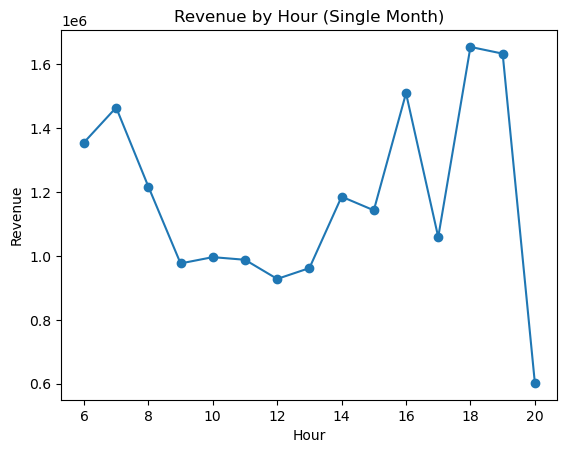

In [72]:
hourly = df.groupby('hour')['revenue'].sum()

plt.plot(hourly.index, hourly.values, marker='o')
plt.title("Revenue by Hour (Single Month)")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

#### **Day-wise Analysis**
- Analyze whether EV charging demand is higher on weekends or weekdays.

In [61]:
import numpy as np

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Realistic probability (weekday more, weekend less)
prob = [0.18, 0.18, 0.18, 0.18, 0.18, 0.05, 0.05]

df['day_name'] = np.random.choice(days, size=len(df), p=prob)

df['week_type'] = df['day_name'].apply(lambda x: 'Weekend' if x in ['Saturday','Sunday'] else 'Weekday')

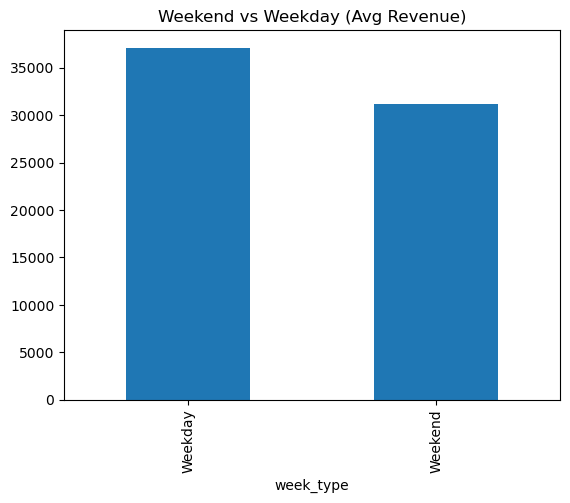

In [64]:
week_analysis = df.groupby('week_type')['revenue'].mean()

week_analysis.plot(kind='bar')
plt.title("Weekend vs Weekday (Avg Revenue)")
plt.show()

#### **Peak Hour Detection**

In [68]:
df['hour'] = pd.to_datetime(df['charging_start_time'], format='%H:%M').dt.hour

In [69]:
print(df['hour'].unique())

[12 15 11 10  8  6  9 17 20 18 14  7 16 19 13]


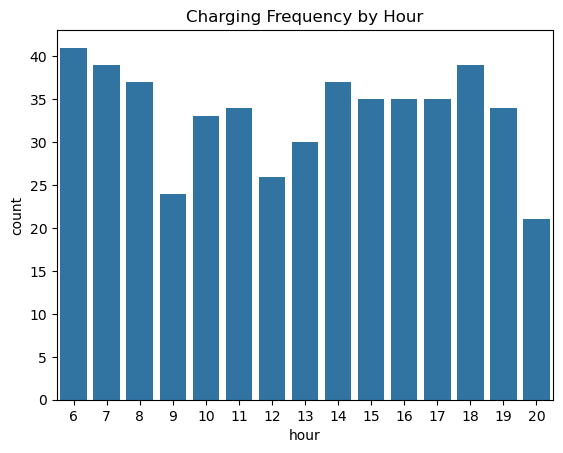

In [70]:
import seaborn as sns

sns.countplot(x='hour', data=df)
plt.title("Charging Frequency by Hour")
plt.show()

#### **Location Analysis**

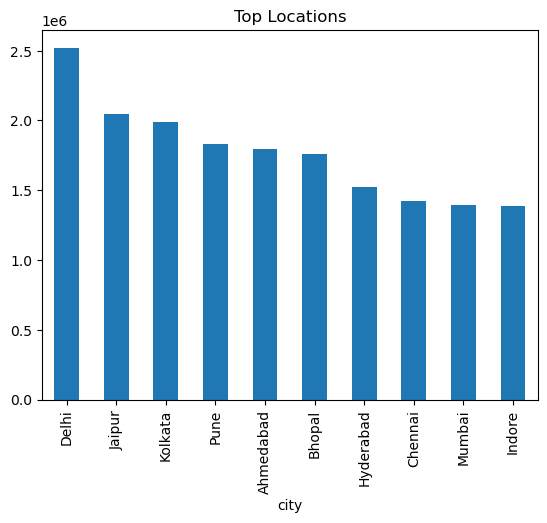

In [60]:
location = df.groupby('city')['revenue'].sum().sort_values(ascending=False)

location.head(10).plot(kind='bar')
plt.title("Top Locations")
plt.show()

#### **Utilization Analysis**

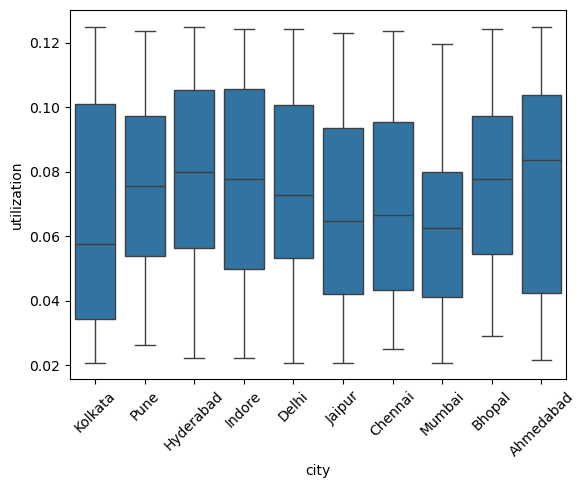

In [51]:
sns.boxplot(x='city', y='utilization', data=df)
plt.xticks(rotation=45)
plt.show()

In [41]:
df['month'].unique()

array([10], dtype=int32)

In [42]:
df['revenue'].describe()

count      500.00000
mean     35348.55600
std      29759.64558
min        102.40000
25%       8208.30000
50%      26625.60000
75%      58102.52500
max      99800.10000
Name: revenue, dtype: float64

In [75]:
df.to_csv("clean_ev_data.csv", index=False)

In [76]:
len(df)

500